In [7]:
# ============================================================================
# xG THESIS — PIPELINE NOTEBOOK
# MSc Econometrics
# Expected Goals Modelling with Tracking & Temporal Features
# StatsBomb Open Data — 5 Competitions, 323 Matches, 7,885 Shots
# ============================================================================

# ── SECTION 1: SETUP & IMPORTS ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from statsbombpy import sb

from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                      StratifiedKFold, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, log_loss, roc_curve,
                              precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from scipy.special import expit
from scipy import stats

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap

print(f"numpy:    {np.__version__}")
print(f"pandas:   {pd.__version__}")
print(f"sklearn:  {__import__('sklearn').__version__}")
print(f"xgboost:  {__import__('xgboost').__version__}")
print(f"lightgbm: {__import__('lightgbm').__version__}")
print(f"catboost: {__import__('catboost').__version__}")
print(f"shap:     {shap.__version__}")

# ── Plot settings ─────────────────────────────────────────────────────────────
BG    = '#0D1B2A'
DARK  = '#1A3A5C'
BLUE  = '#00B4D8'
RED   = '#FF6B6B'
GOLD  = '#FFD166'
GREEN = '#2D6A4F'

plt.rcParams['figure.facecolor'] = BG
plt.rcParams['axes.facecolor']   = BG
plt.rcParams['axes.edgecolor']   = DARK
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = DARK
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.3

numpy:    2.4.6
pandas:   3.0.3
sklearn:  1.6.1
xgboost:  2.1.4
lightgbm: 4.6.0
catboost: 1.2.10
shap:     0.52.0


In [9]:
# ── SECTION 2: CHECKPOINT LOAD & MODEL PREPARATION ────────────────────────────
df_rich = pd.read_pickle('data/df_rich_with_temporal_v2.pkl')

print(f"Loaded: {len(df_rich):,} shots | {df_rich['match_id'].nunique()} matches | "
      f"{df_rich['is_goal'].sum():,} goals ({df_rich['is_goal'].mean()*100:.2f}%) | "
      f"{len(df_rich.columns)} columns")

GOAL_CENTRE = np.array([120, 40])

def is_goalkeeper(player):
    pos = player.get('position')
    if isinstance(pos, dict):
        return pos.get('name') == 'Goalkeeper'
    return bool(player.get('keeper', False))

def get_extra_spatial(row):
    shot_loc = np.array(row['location'])
    freeze = row.get('shot_freeze_frame') or row.get('freeze_frame')

    if not isinstance(freeze, list) or len(freeze) == 0:
        return pd.Series({
            'gk_lateral_position': 0.0,
            'defender_in_shot_path': 0,
            'n_attackers_in_box': 0,
        })

    gk = next((p for p in freeze if is_goalkeeper(p)), None)
    opponents = [p for p in freeze if not p.get('teammate') and not is_goalkeeper(p)]
    teammates = [p for p in freeze if p.get('teammate') and not is_goalkeeper(p)]

    gk_lateral_position = float(abs(gk['location'][1] - 40)) if gk else 0.0

    shot_vec = GOAL_CENTRE - shot_loc
    shot_vec_norm = shot_vec / (np.linalg.norm(shot_vec) + 1e-9)
    defender_in_shot_path = 0
    for opp in opponents:
        opp_vec = np.array(opp['location']) - shot_loc
        proj = float(np.dot(opp_vec, shot_vec_norm))
        if proj > 0:
            perp = float(np.linalg.norm(opp_vec - proj * shot_vec_norm))
            if perp < 1.5 and proj < float(np.linalg.norm(shot_vec)):
                defender_in_shot_path = 1
                break

    n_attackers_in_box = len([p for p in teammates if p['location'][0] > 102])

    return pd.Series({
        'gk_lateral_position': gk_lateral_position,
        'defender_in_shot_path': defender_in_shot_path,
        'n_attackers_in_box': n_attackers_in_box,
    })

extra = df_rich.apply(get_extra_spatial, axis=1)
for col in extra.columns:
    df_rich[col] = extra[col].values

df_model = pd.get_dummies(df_rich, columns=['shot_technique', 'play_pattern'], drop_first=True)
tech_cols = [c for c in df_model.columns if 'shot_technique_' in c]
patt_cols = [c for c in df_model.columns if 'play_pattern_' in c]
dummy_cols = tech_cols + patt_cols

df_model['gk_dist_x_off_line']     = df_model['gk_dist']          * df_model['gk_off_line']
df_model['nearest_opp_x_cone']     = df_model['nearest_opp_dist'] * df_model['cone_opponents']
df_model['distance_x_defenders']   = df_model['distance']         * df_model['defenders_in_box']
df_model['angle_x_cone_adv']       = df_model['angle_rad']        * df_model['cone_advantage']
df_model['header_x_gk_off_line']   = df_model['is_header']        * df_model['gk_off_line']
df_model['pressure_x_nearest_opp'] = df_model['under_pressure']   * df_model['nearest_opp_dist']
df_model['gk_lateral_x_angle']     = df_model['gk_lateral_position'] * df_model['angle_rad']
df_model['no_blocker_x_angle']     = (1 - df_model['defender_in_shot_path']) * df_model['angle_rad']
df_model['overload_x_distance']    = df_model['n_attackers_in_box'] * df_model['distance']

df_model['speed_x_distance']        = df_model['w_speed']              * df_model['distance']
df_model['throughball_x_angle']     = df_model['chain_has_throughball'] * df_model['angle_rad']
df_model['fast_break_x_distance']   = df_model['fast_break']            * df_model['distance']
df_model['chain_dur_x_defenders']   = df_model['chain_duration']        * df_model['defenders_in_box']
df_model['prog_dist_x_gk_off_line'] = df_model['chain_prog_distance']   * df_model['gk_off_line']
df_model['cross_x_is_header']       = df_model['chain_has_cross']       * df_model['is_header']
df_model['speed_x_cone_opp']        = df_model['w_speed']               * df_model['cone_opponents']
df_model['def_line_x_distance']     = df_model['defensive_line_x']      * df_model['distance']

spatial_interaction_cols = [
    'gk_dist_x_off_line', 'nearest_opp_x_cone', 'distance_x_defenders',
    'angle_x_cone_adv', 'header_x_gk_off_line', 'pressure_x_nearest_opp',
    'gk_lateral_x_angle', 'no_blocker_x_angle', 'overload_x_distance'
]
temporal_interaction_cols = [
    'speed_x_distance', 'throughball_x_angle', 'fast_break_x_distance',
    'chain_dur_x_defenders', 'prog_dist_x_gk_off_line', 'cross_x_is_header',
    'speed_x_cone_opp', 'def_line_x_distance'
]

baseline_feats = [
    'distance', 'angle_rad', 'body_part_prob', 'under_pressure',
    'shot_first_time', 'shot_one_on_one', 'shot_open_goal'
]

tracking_feats = [
    'num_opponents', 'cone_opponents', 'gk_angle_error', 'gk_dist',
    'gk_off_line', 'nearest_opp_dist', 'nearest_block_dist',
    'defenders_in_box', 'attackers_ahead', 'cone_advantage',
    'y_centrality', 'near_post_dist', 'far_post_dist',
    'aerial_set_piece', 'is_diving_header',
    'gk_lateral_position', 'defender_in_shot_path', 'n_attackers_in_box'
]

temporal_feats = [
    'w_passes', 'w_carries', 'w_pressure_events', 'w_miscontrol',
    'w_dribble', 'w_under_pressure', 'w_prog_distance', 'w_speed',
    'chain_passes', 'chain_carries', 'chain_duration', 'chain_pressures',
    'chain_under_pressure', 'chain_dribbles', 'chain_has_cross',
    'chain_has_throughball', 'chain_has_switchplay', 'chain_start_x',
    'chain_prog_distance', 'shot_from_rebound', 'fast_break',
    'pass_into_box', 'carry_into_box', 'n_defenders_beaten',
    'final_pass_length', 'final_pass_angle', 'defensive_line_x'
]

tree_baseline          = baseline_feats
tree_tracking          = baseline_feats + tracking_feats
tree_temporal          = baseline_feats + temporal_feats
tree_tracking_temporal = baseline_feats + tracking_feats + temporal_feats
tree_full              = baseline_feats + tracking_feats + temporal_feats + dummy_cols

lr_baseline          = baseline_feats
lr_tracking          = baseline_feats + tracking_feats + spatial_interaction_cols + dummy_cols
lr_temporal          = baseline_feats + temporal_feats + temporal_interaction_cols
lr_tracking_temporal = (baseline_feats + tracking_feats + temporal_feats +
                        spatial_interaction_cols + temporal_interaction_cols + dummy_cols)

all_used = list(set(tree_full + lr_tracking_temporal))
missing = [f for f in all_used if f not in df_model.columns]
if missing:
    print(f"Missing features: {missing}")

print(f"Feature set sizes — baseline: {len(tree_baseline)}, "
      f"tracking: {len(tree_tracking)}, temporal: {len(tree_temporal)}, "
      f"tracking+temporal: {len(tree_tracking_temporal)}, "
      f"tree_full: {len(tree_full)}, lr_tracking_temporal: {len(lr_tracking_temporal)}")

X = df_model[all_used].astype(float)
y = df_model['is_goal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
sb_xg_test = df_model.loc[X_test.index, 'shot_statsbomb_xg']
sb_auc = roc_auc_score(y_test, sb_xg_test)
sb_ll = log_loss(y_test, sb_xg_test)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | "
      f"Goal rate — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")
print(f"StatsBomb benchmark — AUC: {sb_auc:.4f} | Log loss: {sb_ll:.4f}")

def feat_type(f):
    if f in tracking_feats:            return 'Tracking'
    if f in temporal_feats:            return 'Temporal'
    if f in spatial_interaction_cols:  return 'Tracking'
    if f in temporal_interaction_cols: return 'Temporal'
    return 'Baseline'

Loaded: 7,885 shots | 323 matches | 757 goals (9.60%) | 176 columns
Feature set sizes — baseline: 7, tracking: 25, temporal: 34, tracking+temporal: 52, tree_full: 65, lr_tracking_temporal: 82
Train: 6,308 | Test: 1,577 | Goal rate — train: 0.096, test: 0.096
StatsBomb benchmark — AUC: 0.8669 | Log loss: 0.2283


In [10]:
# ── SECTION 3: UNTUNED LEADERBOARD ────────────────────────────────────────────
results = []

def run_model(name, model, feats, scale=False):
    valid_feats = [f for f in feats if f in X_train.columns]
    if scale:
        sc = StandardScaler()
        Xtr = sc.fit_transform(X_train[valid_feats])
        Xte = sc.transform(X_test[valid_feats])
    else:
        Xtr = X_train[valid_feats].values
        Xte = X_test[valid_feats].values
    m = clone(model)
    m.fit(Xtr, y_train)
    p = m.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, p)
    ll = log_loss(y_test, p)
    results.append((name, auc, ll, round(sb_auc - auc, 4), round(auc / sb_auc * 100, 1)))
    return p, m

results.append(("StatsBomb", sb_auc, sb_ll, 0.0, 100.0))

lr_model = LogisticRegression(penalty='elasticnet', solver='saga', C=1.0,
                               l1_ratio=0.15, max_iter=2000, random_state=42)
p_lr_base, _  = run_model("LR — Baseline",          lr_model, lr_baseline,          True)
p_lr_track, _ = run_model("LR — Tracking",          lr_model, lr_tracking,          True)
p_lr_temp, _  = run_model("LR — Temporal",          lr_model, lr_temporal,          True)
p_lr_tt, _    = run_model("LR — Tracking+Temporal", lr_model, lr_tracking_temporal, True)

rf_model = RandomForestClassifier(n_estimators=300, max_depth=10,
                                   min_samples_leaf=5, random_state=42, n_jobs=-1)
p_rf_base, _  = run_model("RF — Baseline",          rf_model, tree_baseline)
p_rf_track, _ = run_model("RF — Tracking",          rf_model, tree_tracking)
p_rf_temp, _  = run_model("RF — Temporal",          rf_model, tree_temporal)
p_rf_tt, _    = run_model("RF — Tracking+Temporal", rf_model, tree_tracking_temporal)

xgb_model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, random_state=42,
                           eval_metric='logloss', tree_method='hist')
p_xgb_base, _  = run_model("XGB — Baseline",          xgb_model, tree_baseline)
p_xgb_track, _ = run_model("XGB — Tracking",          xgb_model, tree_tracking)
p_xgb_temp, _  = run_model("XGB — Temporal",          xgb_model, tree_temporal)
p_xgb_tt, _    = run_model("XGB — Tracking+Temporal", xgb_model, tree_tracking_temporal)

lgb_model = LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.05,
                            random_state=42, verbose=-1, n_jobs=1)
p_lgb_base, _  = run_model("LGB — Baseline",          lgb_model, tree_baseline)
p_lgb_track, _ = run_model("LGB — Tracking",          lgb_model, tree_tracking)
p_lgb_temp, _  = run_model("LGB — Temporal",          lgb_model, tree_temporal)
p_lgb_tt, _    = run_model("LGB — Tracking+Temporal", lgb_model, tree_tracking_temporal)

cb_model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                               random_state=42, verbose=0)
p_cb_base, _  = run_model("CB — Baseline",          cb_model, tree_baseline)
p_cb_track, _ = run_model("CB — Tracking",          cb_model, tree_tracking)
p_cb_temp, _  = run_model("CB — Temporal",          cb_model, tree_temporal)
p_cb_tt, _    = run_model("CB — Tracking+Temporal", cb_model, tree_tracking_temporal)

df_results = pd.DataFrame(results, columns=['Model', 'AUC', 'Log Loss', 'Gap to SB', 'Efficiency (%)'])
print(df_results.sort_values('AUC', ascending=False).to_string(index=False))

                  Model      AUC  Log Loss  Gap to SB  Efficiency (%)
              StatsBomb 0.866918  0.228336     0.0000           100.0
 RF — Tracking+Temporal 0.842053  0.245812     0.0249            97.1
          LR — Tracking 0.841292  0.242987     0.0256            97.0
          RF — Tracking 0.840163  0.244556     0.0268            96.9
 CB — Tracking+Temporal 0.838013  0.245564     0.0289            96.7
          RF — Temporal 0.834117  0.253272     0.0328            96.2
 LR — Tracking+Temporal 0.832055  0.245516     0.0349            96.0
          LR — Temporal 0.831929  0.245744     0.0350            96.0
          LR — Baseline 0.825657  0.254317     0.0413            95.2
          CB — Tracking 0.820793  0.248691     0.0461            94.7
         XGB — Tracking 0.816966  0.251408     0.0500            94.2
          CB — Temporal 0.816738  0.255684     0.0502            94.2
XGB — Tracking+Temporal 0.815554  0.255392     0.0514            94.1
         XGB — Tempo

In [11]:
# ── SECTION 4: HYPERPARAMETER TUNING ──────────────────────────────────────────
tuned_results = []

def tune_model(name, model, param_grid, feats, scale=False, n_iter=20, cv=3):
    valid_feats = [f for f in feats if f in X_train.columns]
    if scale:
        sc = StandardScaler()
        Xtr = sc.fit_transform(X_train[valid_feats])
        Xte = sc.transform(X_test[valid_feats])
    else:
        Xtr = X_train[valid_feats].values
        Xte = X_test[valid_feats].values
    search = RandomizedSearchCV(
        model, param_distributions=param_grid, n_iter=n_iter, cv=cv,
        scoring='roc_auc', random_state=42, n_jobs=1, verbose=0
    )
    search.fit(Xtr, y_train)
    best = search.best_estimator_
    p = best.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, p)
    ll = log_loss(y_test, p)
    tuned_results.append((name, auc, ll, round(sb_auc - auc, 4), round(auc / sb_auc * 100, 1)))
    print(f"{name}: AUC={auc:.4f} | params: {search.best_params_}")
    return best, p

lr_params = {
    'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    'l1_ratio': [0.0, 0.15, 0.3, 0.5, 0.7, 0.85, 1.0],
}
best_lr, p_lr_tuned = tune_model(
    "LR Tuned — Tracking+Temporal",
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=2000, random_state=42),
    lr_params, lr_tracking_temporal, scale=True, n_iter=25, cv=5
)

rf_params = {
    'n_estimators': [300, 500, 700],
    'max_depth': [8, 10, 12, None],
    'min_samples_leaf': [3, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.7, 0.8, 0.9, None],
}
best_rf, p_rf_tuned = tune_model(
    "RF Tuned — Tracking+Temporal",
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, tree_tracking_temporal, n_iter=20, cv=3
)

xgb_params = {
    'n_estimators': [300, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0],
}
best_xgb, p_xgb_tuned = tune_model(
    "XGB Tuned — Full",
    XGBClassifier(random_state=42, eval_metric='logloss', tree_method='hist'),
    xgb_params, tree_full, n_iter=30, cv=3
)

lgb_params = {
    "n_estimators": [100, 200, 300, 400, 500, 700, 900],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07, 0.10],
    "num_leaves": [7, 15, 23, 31, 40, 50, 63],
    "max_depth": [-1, 3, 4, 5, 6, 8, 10],
    "min_child_samples": [10, 20, 30, 50, 75, 100],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [0, 0.01, 0.1, 0.5, 1.0, 2.0],
}
best_lgb, p_lgb_tuned = tune_model(
    "LGB Tuned — Full",
    LGBMClassifier(objective="binary", random_state=42, n_jobs=-1, verbosity=-1),
    lgb_params, tree_full, n_iter=75, cv=5
)

cb_params = {
    'iterations': [300, 500, 700],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bylevel': [0.6, 0.7, 0.8],
}
best_cb, p_cb_tuned = tune_model(
    "CB Tuned — Full",
    CatBoostClassifier(random_state=42, verbose=0),
    cb_params, tree_full, n_iter=20, cv=3
)

df_tuned = pd.DataFrame(tuned_results, columns=['Model', 'AUC', 'Log Loss', 'Gap to SB', 'Efficiency (%)'])
print(df_tuned.to_string(index=False))

LR Tuned — Tracking+Temporal: AUC=0.8497 | params: {'l1_ratio': 1.0, 'C': 0.05}
RF Tuned — Tracking+Temporal: AUC=0.8459 | params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_samples': 0.7, 'max_features': 'sqrt', 'max_depth': None}
XGB Tuned — Full: AUC=0.8350 | params: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.6}
LGB Tuned — Full: AUC=0.8302 | params: {'subsample': 1.0, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
CB Tuned — Full: AUC=0.8304 | params: {'subsample': 0.8, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'iterations': 300, 'depth': 4, 'colsample_bylevel': 0.7}
                       Model      AUC  Log Loss  Gap to SB  Efficiency (%)
LR Tuned — Tracking+Temporal 0.849674  0.242623     0.0172       

In [12]:
# ── SECTION 5: SHAP ANALYSIS ───────────────────────────────────────────────────

def feat_color(f):
    t = feat_type(f)
    if t == 'Tracking': return GREEN
    if t == 'Temporal': return GOLD
    return BLUE

legend_elements = [
    mpatches.Patch(facecolor=BLUE,  label='Baseline'),
    mpatches.Patch(facecolor=GREEN, label='Tracking'),
    mpatches.Patch(facecolor=GOLD,  label='Temporal'),
]

rf_params_best = dict(n_estimators=300, max_depth=10,
                      min_samples_leaf=5, random_state=42, n_jobs=-1)

rf_s1 = RandomForestClassifier(**rf_params_best)
rf_s1.fit(X_train[tree_baseline], y_train)
auc_s1 = roc_auc_score(y_test, rf_s1.predict_proba(X_test[tree_baseline])[:, 1])

rf_s2 = RandomForestClassifier(**rf_params_best)
rf_s2.fit(X_train[tree_tracking], y_train)
auc_s2 = roc_auc_score(y_test, rf_s2.predict_proba(X_test[tree_tracking])[:, 1])

rf_s3 = RandomForestClassifier(**rf_params_best)
rf_s3.fit(X_train[tree_temporal], y_train)
auc_s3 = roc_auc_score(y_test, rf_s3.predict_proba(X_test[tree_temporal])[:, 1])

rf_s4 = RandomForestClassifier(**rf_params_best)
rf_s4.fit(X_train[tree_tracking_temporal], y_train)
auc_s4 = roc_auc_score(y_test, rf_s4.predict_proba(X_test[tree_tracking_temporal])[:, 1])

sc_s5 = StandardScaler()
Xtr_s5 = sc_s5.fit_transform(X_train[lr_tracking_temporal])
Xte_s5 = sc_s5.transform(X_test[lr_tracking_temporal])
lr_s5 = LogisticRegression(penalty='elasticnet', solver='saga', C=0.05, l1_ratio=1.0,
                            max_iter=2000, random_state=42)
lr_s5.fit(Xtr_s5, y_train)
auc_s5 = roc_auc_score(y_test, lr_s5.predict_proba(Xte_s5)[:, 1])

print(f"S1 RF Baseline: {auc_s1:.4f} | S2 RF Tracking: {auc_s2:.4f} | "
      f"S3 RF Temporal: {auc_s3:.4f} | S4 RF T+T: {auc_s4:.4f} | S5 LR T+T: {auc_s5:.4f}")

def get_sv(sv):
    if isinstance(sv, list): return sv[1]
    if sv.ndim == 3:         return sv[:, :, 1]
    return sv

sv_s1 = get_sv(shap.TreeExplainer(rf_s1).shap_values(X_test[tree_baseline]))
sv_s2 = get_sv(shap.TreeExplainer(rf_s2).shap_values(X_test[tree_tracking]))
sv_s3 = get_sv(shap.TreeExplainer(rf_s3).shap_values(X_test[tree_temporal]))
sv_s4 = get_sv(shap.TreeExplainer(rf_s4).shap_values(X_test[tree_tracking_temporal]))
sv_s5 = shap.LinearExplainer(lr_s5, Xtr_s5, feature_names=lr_tracking_temporal).shap_values(Xte_s5)

def shap_table(sv, feats, name, auc, top_n=15):
    imp = pd.DataFrame({
        'feature': feats,
        'mean_abs_shap': np.abs(sv).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False)

    total = imp['mean_abs_shap'].sum()
    imp['pct'] = (imp['mean_abs_shap'] / total * 100).round(1)
    imp['cumul'] = imp['pct'].cumsum().round(1)
    imp['type'] = imp['feature'].apply(feat_type)
    top = imp.head(top_n)

    print(f"\n{name} | AUC={auc:.4f}")
    print(top[['feature', 'mean_abs_shap', 'pct', 'cumul', 'type']].to_string(index=False))

    b   = imp[imp['type']=='Baseline']['mean_abs_shap'].sum()/total*100
    t   = imp[imp['type']=='Tracking']['mean_abs_shap'].sum()/total*100
    tmp = imp[imp['type']=='Temporal']['mean_abs_shap'].sum()/total*100
    print(f"Baseline: {b:.1f}% | Tracking: {t:.1f}% | Temporal: {tmp:.1f}%")

    return imp, (b, t, tmp)

imp_s1, c1 = shap_table(sv_s1, tree_baseline,          "S1: RF Baseline",   auc_s1)
imp_s2, c2 = shap_table(sv_s2, tree_tracking,          "S2: RF Tracking",   auc_s2)
imp_s3, c3 = shap_table(sv_s3, tree_temporal,          "S3: RF Temporal",   auc_s3)
imp_s4, c4 = shap_table(sv_s4, tree_tracking_temporal, "S4: RF T+T",        auc_s4)
imp_s5, c5 = shap_table(sv_s5, lr_tracking_temporal,   "S5: LR T+T (Best)", auc_s5)

S1 RF Baseline: 0.7910 | S2 RF Tracking: 0.8402 | S3 RF Temporal: 0.8341 | S4 RF T+T: 0.8421 | S5 LR T+T: 0.8497


Background dataset has 6308 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6308 when initializing the masker.



S1: RF Baseline | AUC=0.7910
        feature  mean_abs_shap  pct  cumul     type
      angle_rad       0.037771 36.7   36.7 Baseline
       distance       0.026928 26.1   62.8 Baseline
 body_part_prob       0.014678 14.2   77.0 Baseline
 under_pressure       0.008843  8.6   85.6 Baseline
shot_first_time       0.006387  6.2   91.8 Baseline
shot_one_on_one       0.004717  4.6   96.4 Baseline
 shot_open_goal       0.003689  3.6  100.0 Baseline
Baseline: 100.0% | Tracking: 0.0% | Temporal: 0.0%

S2: RF Tracking | AUC=0.8402
              feature  mean_abs_shap  pct  cumul     type
            angle_rad       0.019000 14.3   14.3 Baseline
       near_post_dist       0.012206  9.2   23.5 Tracking
             distance       0.011231  8.4   31.9 Baseline
          gk_off_line       0.010600  8.0   39.9 Tracking
     nearest_opp_dist       0.010207  7.7   47.6 Tracking
defender_in_shot_path       0.010008  7.5   55.1 Tracking
              gk_dist       0.009601  7.2   62.3 Tracking
        f

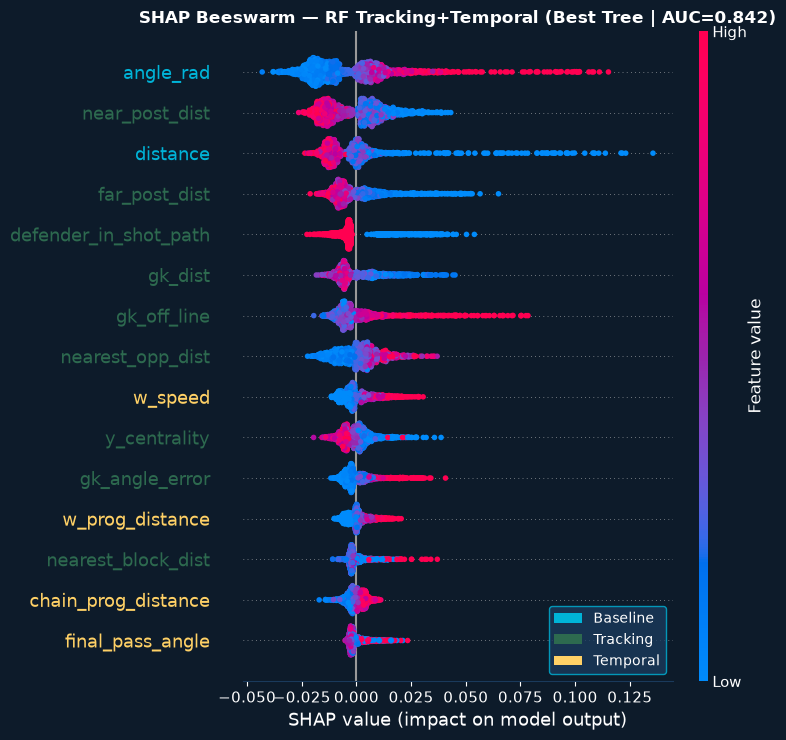

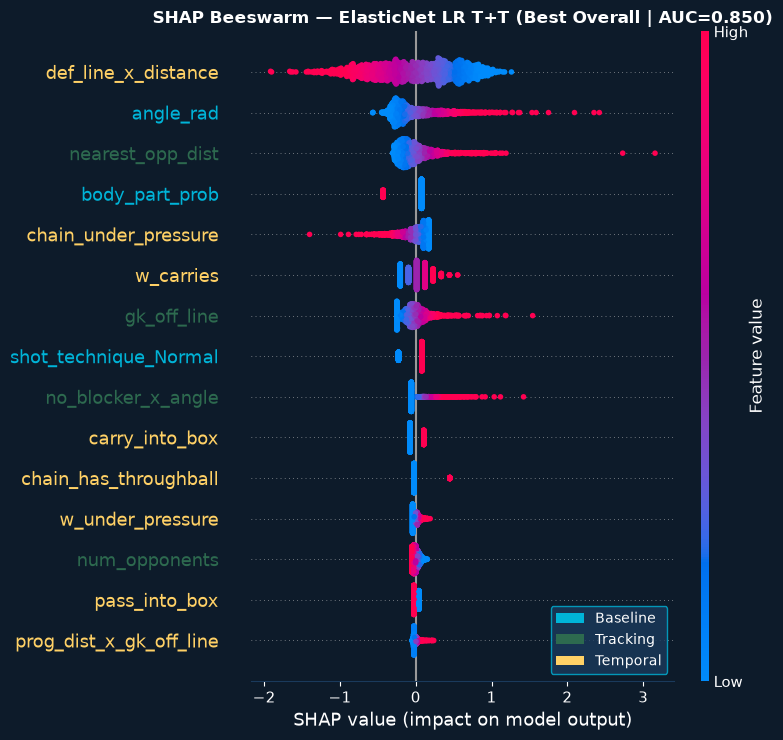

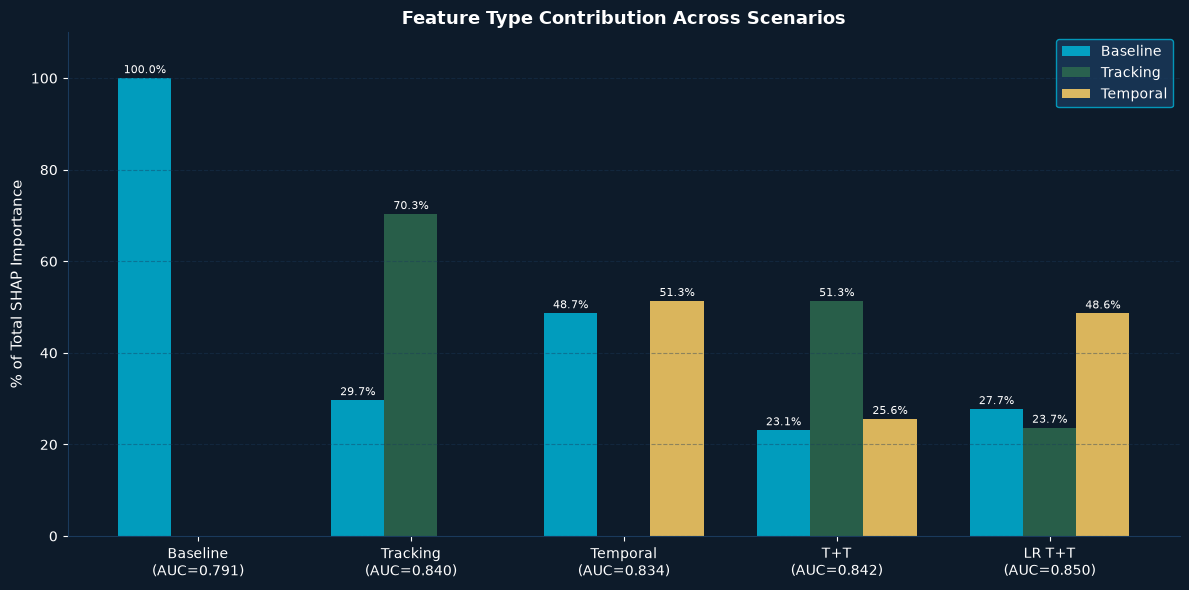

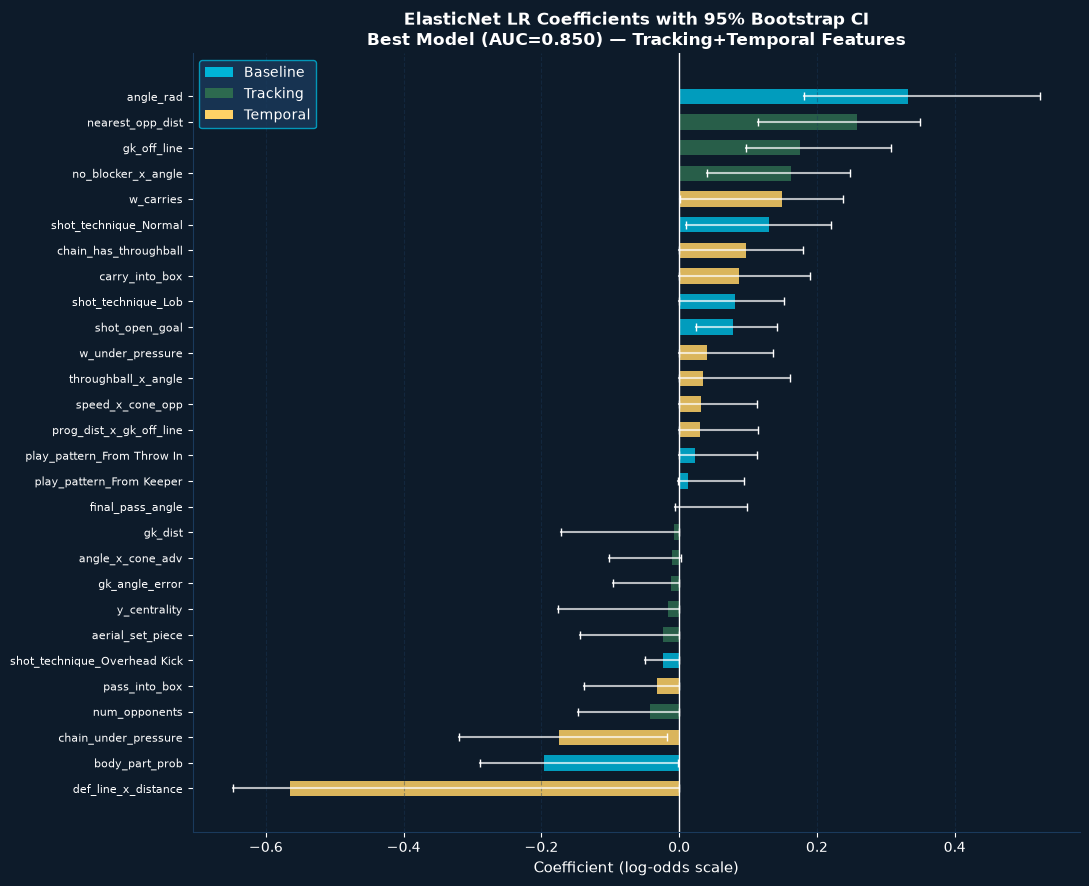

In [16]:
# ── SHAP Plots ─────────────────────────────────────────────────────────────────
os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
shap.summary_plot(sv_s4, X_test[tree_tracking_temporal], feature_names=tree_tracking_temporal,
                  max_display=15, show=False, plot_type='dot')
plt.title(f'SHAP Beeswarm — RF Tracking+Temporal (Best Tree | AUC={auc_s4:.3f})',
          color='white', fontsize=12, fontweight='bold')
plt.gcf().patch.set_facecolor(BG)
plt.gca().set_facecolor(BG)
plt.gca().tick_params(colors='white')
plt.gca().xaxis.label.set_color('white')
for label in plt.gca().get_yticklabels():
    label.set_color(feat_color(label.get_text()))
plt.gca().legend(handles=legend_elements, facecolor=DARK, labelcolor='white',
                 edgecolor=BLUE, fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('figures/shap_beeswarm_RF_TT.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
shap.summary_plot(sv_s5, Xte_s5, feature_names=lr_tracking_temporal,
                  max_display=15, show=False, plot_type='dot')
plt.title(f'SHAP Beeswarm — ElasticNet LR T+T (Best Overall | AUC={auc_s5:.3f})',
          color='white', fontsize=12, fontweight='bold')
plt.gcf().patch.set_facecolor(BG)
plt.gca().set_facecolor(BG)
plt.gca().tick_params(colors='white')
plt.gca().xaxis.label.set_color('white')
for label in plt.gca().get_yticklabels():
    label.set_color(feat_color(label.get_text()))
plt.gca().legend(handles=legend_elements, facecolor=DARK, labelcolor='white',
                 edgecolor=BLUE, fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('figures/shap_beeswarm_LR_best.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

scenario_labels = [
    f'Baseline\n(AUC={auc_s1:.3f})', f'Tracking\n(AUC={auc_s2:.3f})',
    f'Temporal\n(AUC={auc_s3:.3f})', f'T+T\n(AUC={auc_s4:.3f})',
    f'LR T+T\n(AUC={auc_s5:.3f})'
]
base_vals  = [c1[0], c2[0], c3[0], c4[0], c5[0]]
track_vals = [c1[1], c2[1], c3[1], c4[1], c5[1]]
temp_vals  = [c1[2], c2[2], c3[2], c4[2], c5[2]]

x = np.arange(len(scenario_labels))
width = 0.25
bars1 = ax.bar(x - width, base_vals,  width, label='Baseline', color=BLUE,  alpha=0.85)
bars2 = ax.bar(x,          track_vals, width, label='Tracking', color=GREEN, alpha=0.85)
bars3 = ax.bar(x + width,  temp_vals,  width, label='Temporal', color=GOLD,  alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        if bar.get_height() > 1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{bar.get_height():.1f}%', ha='center', va='bottom',
                    color='white', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, color='white', fontsize=10)
ax.set_ylabel('% of Total SHAP Importance', color='white', fontsize=11)
ax.set_title('Feature Type Contribution Across Scenarios', color='white',
             fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor=DARK, labelcolor='white', edgecolor=BLUE, fontsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color(DARK)
ax.grid(axis='y', color=DARK, linestyle='--', alpha=0.4)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('figures/shap_contribution_evolution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

plot_df = nonzero.sort_values('coef')
fig, ax = plt.subplots(figsize=(11, max(8, len(plot_df)*0.32)))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

colors = [feat_color(f) for f in plot_df['feature']]
ax.barh(range(len(plot_df)), plot_df['coef'], color=colors, alpha=0.85, height=0.6)
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row['ci_lower'], row['ci_upper']], [i, i], color='white', linewidth=1.5, alpha=0.7)
    ax.plot(row['ci_lower'], i, '|', color='white', markersize=6)
    ax.plot(row['ci_upper'], i, '|', color='white', markersize=6)

ax.axvline(x=0, color='white', linewidth=1)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature'], color='white', fontsize=8)
ax.set_xlabel('Coefficient (log-odds scale)', color='white', fontsize=11)
ax.set_title(f'ElasticNet LR Coefficients with 95% Bootstrap CI\n'
             f'Best Model (AUC={auc_s5:.3f}) — Tracking+Temporal Features',
             color='white', fontsize=12, fontweight='bold')
ax.tick_params(colors='white')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color(DARK)
ax.grid(axis='x', color=DARK, linestyle='--', alpha=0.4)
ax.legend(handles=legend_elements, facecolor=DARK, labelcolor='white', edgecolor=BLUE, fontsize=10)
plt.tight_layout()
plt.savefig('figures/lr_coefficients.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

In [13]:
# ── LR COEFFICIENT ANALYSIS WITH BOOTSTRAP CIs ────────────────────────────────
np.random.seed(42)
n_boot = 500
boot_coefs = np.zeros((n_boot, len(lr_tracking_temporal)))

for i in range(n_boot):
    idx = np.random.choice(len(Xtr_s5), len(Xtr_s5), replace=True)
    Xb, yb = Xtr_s5[idx], y_train.iloc[idx]
    lb = LogisticRegression(penalty='elasticnet', solver='saga', C=0.05, l1_ratio=1.0,
                             max_iter=500, random_state=i)
    lb.fit(Xb, yb)
    boot_coefs[i] = lb.coef_[0]

ci_lower = np.percentile(boot_coefs, 2.5, axis=0)
ci_upper = np.percentile(boot_coefs, 97.5, axis=0)

coef_df = pd.DataFrame({
    'feature': lr_tracking_temporal,
    'coef': lr_s5.coef_[0],
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
    'abs_coef': np.abs(lr_s5.coef_[0]),
    'odds_ratio': np.exp(lr_s5.coef_[0]),
    'or_lower': np.exp(ci_lower),
    'or_upper': np.exp(ci_upper),
})
coef_df['type'] = coef_df['feature'].apply(feat_type)
coef_df['significant'] = ~((coef_df['ci_lower'] < 0) & (coef_df['ci_upper'] > 0))
coef_df['zeroed'] = coef_df['coef'] == 0

nonzero = coef_df[~coef_df['zeroed']].sort_values('coef', ascending=False)
zeroed = coef_df[coef_df['zeroed']]

print(f"Features zeroed by ElasticNet: {len(zeroed)}")
print(nonzero[['feature', 'coef', 'odds_ratio', 'or_lower', 'or_upper', 'type', 'significant']].to_string(index=False))

Features zeroed by ElasticNet: 54
                     feature      coef  odds_ratio  or_lower  or_upper     type  significant
                   angle_rad  0.331603    1.393200  1.199223  1.687743 Baseline         True
            nearest_opp_dist  0.258504    1.294992  1.121477  1.419005 Tracking         True
                 gk_off_line  0.175050    1.191306  1.101981  1.360821 Tracking         True
          no_blocker_x_angle  0.162379    1.176306  1.041299  1.280998 Tracking         True
                   w_carries  0.149410    1.161149  1.000840  1.267770 Temporal         True
       shot_technique_Normal  0.129830    1.138634  1.010657  1.247116 Baseline         True
       chain_has_throughball  0.097593    1.102513  1.000000  1.197305 Temporal         True
              carry_into_box  0.086596    1.090456  1.000000  1.209608 Temporal         True
          shot_technique_Lob  0.081583    1.085004  1.000000  1.164422 Baseline         True
              shot_open_goal  0.0786

In [17]:
# ── SECTION 6: DIAGNOSTICS ────────────────────────────────────────────────────
p_lr_best  = lr_s5.predict_proba(Xte_s5)[:, 1]
p_rf_best  = rf_s4.predict_proba(X_test[tree_tracking_temporal])[:, 1]

valid_xgb = [f for f in tree_full if f in X_test.columns]
p_xgb_best = best_xgb.predict_proba(X_test[valid_xgb])[:, 1]

p_sb = sb_xg_test.values

auc_lr  = roc_auc_score(y_test, p_lr_best)
auc_rf  = roc_auc_score(y_test, p_rf_best)
auc_xgb = roc_auc_score(y_test, p_xgb_best)
auc_sb  = roc_auc_score(y_test, p_sb)

print("AUC, Log Loss, and Average Precision:")
for name, p in [("StatsBomb", p_sb), ("LR T+T Tuned", p_lr_best),
                 ("RF T+T", p_rf_best), ("XGB Tuned Full", p_xgb_best)]:
    auc = roc_auc_score(y_test, p)
    ll = log_loss(y_test, p)
    ap = average_precision_score(y_test, p)
    print(f"{name:<20} AUC={auc:.4f}  LogLoss={ll:.4f}  AP={ap:.4f}")

print(f"\nActual conversion rate: {y_test.mean():.4f}")
print("Calibration check (mean predicted xG):")
for name, p in [("StatsBomb", p_sb), ("LR T+T Tuned", p_lr_best),
                 ("RF T+T", p_rf_best), ("XGB Tuned Full", p_xgb_best)]:
    print(f"{name:<20} {p.mean():.4f}")

print("\nROC gap at low FPR (FPR < 0.1):")
for name, p in [("StatsBomb", p_sb), ("LR T+T Tuned", p_lr_best),
                 ("RF T+T", p_rf_best), ("XGB Tuned Full", p_xgb_best)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    mask = fpr < 0.1
    if mask.sum() > 1:
        print(f"{name:<20} Mean TPR at FPR<0.1: {tpr[mask].mean():.4f}")

AUC, Log Loss, and Average Precision:
StatsBomb            AUC=0.8669  LogLoss=0.2283  AP=0.5081
LR T+T Tuned         AUC=0.8497  LogLoss=0.2426  AP=0.4572
RF T+T               AUC=0.8421  LogLoss=0.2458  AP=0.4361
XGB Tuned Full       AUC=0.8350  LogLoss=0.2464  AP=0.4089

Actual conversion rate: 0.0958
Calibration check (mean predicted xG):
StatsBomb            0.0937
LR T+T Tuned         0.0939
RF T+T               0.0952
XGB Tuned Full       0.0895

ROC gap at low FPR (FPR < 0.1):
StatsBomb            Mean TPR at FPR<0.1: 0.3607
LR T+T Tuned         Mean TPR at FPR<0.1: 0.3292
RF T+T               Mean TPR at FPR<0.1: 0.3157
XGB Tuned Full       Mean TPR at FPR<0.1: 0.2802


In [18]:
# ── SECTION 7: HEADER GAP ANALYSIS ────────────────────────────────────────────
is_header_test = df_model.loc[X_test.index, 'is_header']
mask_foot = is_header_test == 0
mask_head = is_header_test == 1

print(f"Foot shots: {mask_foot.sum():,} ({mask_foot.sum()/len(mask_foot)*100:.1f}%) | "
      f"Headers: {mask_head.sum():,} ({mask_head.sum()/len(mask_head)*100:.1f}%)")
print(f"Goal rate — Foot: {y_test[mask_foot].mean():.3f} | Header: {y_test[mask_head].mean():.3f}")

models_gap = [
    ("StatsBomb",      p_sb),
    ("LR T+T Tuned",   p_lr_best),
    ("RF T+T",         p_rf_best),
    ("XGB Tuned Full", p_xgb_best),
]

gap_results = []
print(f"\n{'Model':<20} {'Foot AUC':>9} {'Head AUC':>9} {'Gap':>8}")
for name, p in models_gap:
    auc_foot = roc_auc_score(y_test[mask_foot], p[mask_foot])
    auc_head = roc_auc_score(y_test[mask_head], p[mask_head])
    gap = auc_head - auc_foot
    gap_results.append((name, auc_foot, auc_head, gap))
    print(f"{name:<20} {auc_foot:>9.4f} {auc_head:>9.4f} {gap:>+8.4f}")

print(f"\n{'Model':<20} {'Foot gap':>10} {'Head gap':>10} {'Ratio':>8}")
sb_foot, sb_head = gap_results[0][1], gap_results[0][2]
for name, foot, head, gap in gap_results[1:]:
    foot_gap = sb_foot - foot
    head_gap = sb_head - head
    ratio = head_gap / foot_gap if foot_gap > 0 else 0
    print(f"{name:<20} {foot_gap:>10.4f} {head_gap:>10.4f} {ratio:>8.2f}x")

Foot shots: 1,267 (80.3%) | Headers: 310 (19.7%)
Goal rate — Foot: 0.088 | Header: 0.126

Model                 Foot AUC  Head AUC      Gap
StatsBomb               0.8776    0.8145  -0.0631
LR T+T Tuned            0.8619    0.8028  -0.0591
RF T+T                  0.8588    0.7728  -0.0860
XGB Tuned Full          0.8472    0.7780  -0.0692

Model                  Foot gap   Head gap    Ratio
LR T+T Tuned             0.0157     0.0116     0.74x
RF T+T                   0.0188     0.0416     2.22x
XGB Tuned Full           0.0304     0.0364     1.20x


In [19]:
# ── SECTION 8: COMPETITION & GENDER AUC BREAKDOWN ─────────────────────────────
test_meta = df_model.loc[X_test.index, ['competition_name', 'shot_statsbomb_xg', 'is_header']].copy()
test_meta['is_goal'] = y_test.values
test_meta['p_lr'] = p_lr_best
test_meta['p_rf'] = p_rf_best
test_meta['p_xgb'] = p_xgb_best
test_meta['p_sb'] = p_sb

gender_map = {
    'UEFA Euro': 'Men', 'FIFA World Cup': 'Men', '1. Bundesliga': 'Men',
    "UEFA Women's Euro": 'Women', "Women's World Cup": 'Women',
}
test_meta['gender'] = test_meta['competition_name'].map(gender_map)

type_map = {
    'UEFA Euro': 'International', 'FIFA World Cup': 'International',
    "UEFA Women's Euro": 'International', "Women's World Cup": 'International',
    '1. Bundesliga': 'Domestic',
}
test_meta['comp_type'] = test_meta['competition_name'].map(type_map)

print(f"{'Competition':<25} {'n':>5} {'Goals':>6} {'Conv%':>6} "
      f"{'SB':>7} {'LR':>7} {'RF':>7} {'XGB':>7} {'Gap LR':>8}")
comp_results = []
for comp in sorted(test_meta['competition_name'].unique()):
    sub = test_meta[test_meta['competition_name'] == comp]
    if sub['is_goal'].sum() < 5:
        continue
    auc_sb = roc_auc_score(sub['is_goal'], sub['p_sb'])
    auc_lr = roc_auc_score(sub['is_goal'], sub['p_lr'])
    auc_rf = roc_auc_score(sub['is_goal'], sub['p_rf'])
    auc_xgb = roc_auc_score(sub['is_goal'], sub['p_xgb'])
    conv = sub['is_goal'].mean() * 100
    comp_results.append((comp, len(sub), sub['is_goal'].sum(), conv, auc_sb, auc_lr, auc_rf, auc_xgb))
    print(f"{comp:<25} {len(sub):>5} {sub['is_goal'].sum():>6} {conv:>6.1f} "
          f"{auc_sb:>7.4f} {auc_lr:>7.4f} {auc_rf:>7.4f} {auc_xgb:>7.4f} {auc_sb-auc_lr:>+8.4f}")

print(f"\n{'Gender':<10} {'n':>5} {'Goals':>6} {'Conv%':>6} "
      f"{'SB':>7} {'LR':>7} {'RF':>7} {'XGB':>7} {'Gap LR':>8}")
gender_results = []
for gender in ['Men', 'Women']:
    sub = test_meta[test_meta['gender'] == gender]
    if sub['is_goal'].sum() < 5:
        continue
    auc_sb = roc_auc_score(sub['is_goal'], sub['p_sb'])
    auc_lr = roc_auc_score(sub['is_goal'], sub['p_lr'])
    auc_rf = roc_auc_score(sub['is_goal'], sub['p_rf'])
    auc_xgb = roc_auc_score(sub['is_goal'], sub['p_xgb'])
    conv = sub['is_goal'].mean() * 100
    gender_results.append((gender, len(sub), sub['is_goal'].sum(), conv, auc_sb, auc_lr, auc_rf, auc_xgb))
    print(f"{gender:<10} {len(sub):>5} {sub['is_goal'].sum():>6} {conv:>6.1f} "
          f"{auc_sb:>7.4f} {auc_lr:>7.4f} {auc_rf:>7.4f} {auc_xgb:>7.4f} {auc_sb-auc_lr:>+8.4f}")

print(f"\n{'Group':<20} {'n':>5} {'SB':>7} {'LR':>7} {'Gap':>8}")
for gender in ['Men', 'Women']:
    for shot_type, header_val in [('Foot', 0), ('Header', 1)]:
        sub = test_meta[(test_meta['gender'] == gender) & (test_meta['is_header'] == header_val)]
        if sub['is_goal'].sum() < 5:
            continue
        auc_sb = roc_auc_score(sub['is_goal'], sub['p_sb'])
        auc_lr = roc_auc_score(sub['is_goal'], sub['p_lr'])
        print(f"{gender} — {shot_type:<10} {len(sub):>5} {auc_sb:>7.4f} {auc_lr:>7.4f} {auc_sb-auc_lr:>+8.4f}")

Competition                   n  Goals  Conv%      SB      LR      RF     XGB   Gap LR
1. Bundesliga               153     17   11.1  0.8880  0.8452  0.8633  0.8642  +0.0428
FIFA World Cup              267     28   10.5  0.8631  0.8386  0.8465  0.8144  +0.0245
UEFA Euro                   514     44    8.6  0.8500  0.8547  0.8219  0.8203  -0.0046
UEFA Women's Euro           326     31    9.5  0.8584  0.8359  0.8354  0.8396  +0.0225
Women's World Cup           317     31    9.8  0.8877  0.8724  0.8688  0.8539  +0.0152

Gender         n  Goals  Conv%      SB      LR      RF     XGB   Gap LR
Men          934     89    9.5  0.8628  0.8480  0.8367  0.8281  +0.0148
Women        643     62    9.6  0.8737  0.8529  0.8500  0.8446  +0.0208

Group                    n      SB      LR      Gap
Men — Foot         756  0.8795  0.8750  +0.0044
Men — Header       178  0.7838  0.7448  +0.0390
Women — Foot         511  0.8745  0.8443  +0.0302
Women — Header       132  0.8517  0.8737  -0.0220


In [20]:
# ── SECTION 9: DELONG TESTS ────────────────────────────────────────────────────
from scipy.stats import norm

def delong_auc_test(y_true, pred1, pred2):
    y_true = np.asarray(y_true)
    pred1 = np.asarray(pred1)
    pred2 = np.asarray(pred2)
    pos = y_true == 1
    neg = y_true == 0
    n_pos = np.sum(pos)
    n_neg = np.sum(neg)

    def structural_components(pred):
        pos_scores = pred[pos]
        neg_scores = pred[neg]
        comparisons = (pos_scores[:, None] > neg_scores[None, :]).astype(float)
        comparisons += 0.5 * (pos_scores[:, None] == neg_scores[None, :])
        V10 = comparisons.mean(axis=1)
        V01 = comparisons.mean(axis=0)
        auc = V10.mean()
        return auc, V10, V01

    auc1, V10_1, V01_1 = structural_components(pred1)
    auc2, V10_2, V01_2 = structural_components(pred2)
    auc_diff = auc1 - auc2
    sx = np.cov(np.vstack([V10_1, V10_2]), ddof=1)
    sy = np.cov(np.vstack([V01_1, V01_2]), ddof=1)
    covariance = sx / n_pos + sy / n_neg
    variance = covariance[0, 0] + covariance[1, 1] - 2 * covariance[0, 1]
    z = auc_diff / np.sqrt(variance)
    p = 2 * norm.sf(abs(z))
    return auc1, auc2, auc_diff, z, p

def holm_correct(comparisons):
    names = [c[0] for c in comparisons]
    raw_p = np.array([c[1] for c in comparisons])
    m = len(raw_p)
    order = np.argsort(raw_p)
    sorted_p = raw_p[order]
    holm_sorted = np.empty(m)
    prev = 0.0
    for i, p in enumerate(sorted_p):
        adj = min(max(p * (m - i), prev), 1.0)
        holm_sorted[i] = adj
        prev = adj
    holm_p = np.empty(m)
    holm_p[order] = holm_sorted
    return pd.DataFrame({
        "Comparison": names, "Raw p": raw_p.round(4),
        "Holm p": holm_p.round(4),
        "Significant": ["Yes" if p < 0.05 else "No" for p in holm_p]
    })

y = np.asarray(y_test)

untuned_baseline = {"LR": p_lr_base, "RF": p_rf_base, "XGB": p_xgb_base, "CB": p_cb_base, "LGB": p_lgb_base}
untuned_tt = {"LR": p_lr_tt, "RF": p_rf_tt, "XGB": p_xgb_tt, "CB": p_cb_tt, "LGB": p_lgb_tt}

table_53_rows = []
for model in ["LR", "RF", "XGB", "CB", "LGB"]:
    auc1, auc2, delta, z, p = delong_auc_test(y, np.asarray(untuned_tt[model]), np.asarray(untuned_baseline[model]))
    table_53_rows.append((model, auc2, auc1, delta, p))

df_53 = pd.DataFrame(table_53_rows, columns=["Model", "Baseline AUC", "T+T AUC", "ΔAUC", "Raw p"])
holm_53 = holm_correct([(r[0], r[4]) for r in table_53_rows])
df_53 = df_53.merge(holm_53[["Comparison", "Holm p", "Significant"]], left_on="Model", right_on="Comparison").drop(columns="Comparison")
print("Table 5.3 — Feature engineering contribution:")
print(df_53.to_string(index=False))

tuned_best = {"LR": p_lr_tuned, "RF": p_rf_tuned, "XGB": p_xgb_tuned, "CB": p_cb_tuned, "LGB": p_lgb_tuned}
print(f"\nSanity check — LGB tuned AUC: {roc_auc_score(y, tuned_best['LGB']):.4f} (should be 0.8302)")

table_6_rows = []
for model in ["LR", "RF", "XGB", "CB", "LGB"]:
    auc1, auc2, delta, z, p = delong_auc_test(y, np.asarray(tuned_best[model]), p_sb)
    table_6_rows.append((model, auc1, auc2, delta, p))

holm_6 = holm_correct([(r[0], r[4]) for r in table_6_rows])
df_6 = pd.DataFrame(table_6_rows, columns=["Model", "Model AUC", "StatsBomb AUC", "ΔAUC", "Raw p"])
df_6 = df_6.merge(holm_6[["Comparison", "Holm p", "Significant"]], left_on="Model", right_on="Comparison").drop(columns="Comparison")
print("\nAppendix Table 6 — Tuned models vs StatsBomb:")
print(df_6.to_string(index=False))

Table 5.3 — Feature engineering contribution:
Model  Baseline AUC  T+T AUC     ΔAUC    Raw p  Holm p Significant
   LR      0.825657 0.832055 0.006397 0.659862  0.6599          No
   RF      0.791035 0.842053 0.051018 0.000290  0.0014         Yes
  XGB      0.781810 0.815554 0.033744 0.033402  0.0668          No
   CB      0.795696 0.838013 0.042317 0.003484  0.0105         Yes
  LGB      0.740224 0.801246 0.061021 0.002301  0.0092         Yes

Sanity check — LGB tuned AUC: 0.8302 (should be 0.8302)

Appendix Table 6 — Tuned models vs StatsBomb:
Model  Model AUC  StatsBomb AUC      ΔAUC    Raw p  Holm p Significant
   LR   0.849674       0.866918 -0.017244 0.084033  0.0947          No
   RF   0.845941       0.866918 -0.020977 0.047374  0.0947          No
  XGB   0.835045       0.866918 -0.031873 0.002843  0.0085         Yes
   CB   0.830406       0.866918 -0.036512 0.001927  0.0077         Yes
  LGB   0.830220       0.866918 -0.036698 0.000757  0.0038         Yes


In [21]:
# ── SECTION 10: BUNDESLIGA BETTING CASE STUDY ─────────────────────────────────
from scipy.stats import poisson

odds_df = pd.read_csv('data/D1.csv')

team_map = {
    'Leverkusen': 'Bayer Leverkusen', 'Bayern Munich': 'Bayern Munich',
    'Augsburg': 'Augsburg', "M'gladbach": 'Borussia Mönchengladbach',
    'Dortmund': 'Borussia Dortmund', 'Darmstadt': 'Darmstadt 98',
    'Ein Frankfurt': 'Eintracht Frankfurt', 'Heidenheim': 'FC Heidenheim',
    'FC Koln': 'FC Köln', 'Mainz': 'FSV Mainz 05', 'Freiburg': 'Freiburg',
    'Hoffenheim': 'Hoffenheim', 'RB Leipzig': 'RB Leipzig',
    'Stuttgart': 'VfB Stuttgart', 'Union Berlin': 'Union Berlin',
    'Werder Bremen': 'Werder Bremen', 'Wolfsburg': 'Wolfsburg', 'Bochum': 'Bochum',
}

odds_df['HomeTeam_sb'] = odds_df['HomeTeam'].map(team_map)
odds_df['AwayTeam_sb'] = odds_df['AwayTeam'].map(team_map)
odds_df['Date'] = pd.to_datetime(odds_df['Date'], dayfirst=True)

buli_matches = sb.matches(competition_id=9, season_id=281)
buli_matches['match_date'] = pd.to_datetime(buli_matches['match_date'])

merged = buli_matches.merge(
    odds_df, left_on=['home_team', 'away_team'],
    right_on=['HomeTeam_sb', 'AwayTeam_sb'], how='inner'
)
print(f"Matched: {len(merged)}/{len(buli_matches)} matches")

buli_shots = df_rich[df_rich['competition_name'] == '1. Bundesliga'].copy()
buli_idx = buli_shots.index
X_buli = df_model.loc[buli_idx, [f for f in lr_tracking_temporal if f in df_model.columns]].astype(float)
X_buli_scaled = sc_s5.transform(X_buli)
buli_shots['p_lr'] = lr_s5.predict_proba(X_buli_scaled)[:, 1]
buli_shots['p_sb'] = df_model.loc[buli_idx, 'shot_statsbomb_xg'].values

buli_shots = buli_shots.merge(
    buli_matches[['match_id', 'home_team', 'away_team']], on='match_id', how='left'
)

team_col = None
for col in ['team', 'possession_team']:
    if col in buli_shots.columns:
        team_col = col
        break

if team_col:
    buli_shots['is_home_shot'] = (buli_shots[team_col] == buli_shots['home_team']).astype(int)
else:
    buli_shots['is_home_shot'] = (buli_shots['location'].apply(lambda l: l[0] > 60)).astype(int)

match_xg_split = buli_shots.groupby(['match_id', 'is_home_shot']).agg(
    xg_lr=('p_lr', 'sum'), xg_sb=('p_sb', 'sum'),
    goals=('is_goal', 'sum'), shots=('is_goal', 'count')
).reset_index()

home_xg = match_xg_split[match_xg_split['is_home_shot']==1].set_index('match_id')
away_xg = match_xg_split[match_xg_split['is_home_shot']==0].set_index('match_id')

match_level = pd.DataFrame({
    'match_id': home_xg.index,
    'home_xg_lr': home_xg['xg_lr'], 'away_xg_lr': away_xg['xg_lr'],
    'home_xg_sb': home_xg['xg_sb'], 'away_xg_sb': away_xg['xg_sb'],
    'home_goals_xg': home_xg['goals'], 'away_goals_xg': away_xg['goals'],
}).reset_index(drop=True)

match_level = match_level.merge(
    merged[['match_id', 'home_score', 'away_score', 'AvgCH', 'AvgCD', 'AvgCA']],
    on='match_id', how='inner'
)

match_level['actual_result'] = np.where(
    match_level['home_score'] > match_level['away_score'], 'H',
    np.where(match_level['home_score'] < match_level['away_score'], 'A', 'D')
)

def poisson_match_probs(lambda_home, lambda_away, max_goals=10):
    p_home = np.array([poisson.pmf(i, lambda_home) for i in range(max_goals+1)])
    p_away = np.array([poisson.pmf(j, lambda_away) for j in range(max_goals+1)])
    score_matrix = np.outer(p_home, p_away)
    return np.tril(score_matrix, k=-1).sum(), np.trace(score_matrix), np.triu(score_matrix, k=1).sum()

model_probs, sb_probs = [], []
for _, row in match_level.iterrows():
    p_h, p_d, p_a = poisson_match_probs(row['home_xg_lr'], row['away_xg_lr'])
    model_probs.append({'p_home': p_h, 'p_draw': p_d, 'p_away': p_a})
    p_h_sb, p_d_sb, p_a_sb = poisson_match_probs(row['home_xg_sb'], row['away_xg_sb'])
    sb_probs.append({'p_home': p_h_sb, 'p_draw': p_d_sb, 'p_away': p_a_sb})

model_probs_df = pd.DataFrame(model_probs)
sb_probs_df = pd.DataFrame(sb_probs)
match_level['model_p_home'] = model_probs_df['p_home'].values
match_level['model_p_draw'] = model_probs_df['p_draw'].values
match_level['model_p_away'] = model_probs_df['p_away'].values
match_level['sb_p_home'] = sb_probs_df['p_home'].values
match_level['sb_p_draw'] = sb_probs_df['p_draw'].values
match_level['sb_p_away'] = sb_probs_df['p_away'].values

match_level['mkt_raw_home'] = 1 / match_level['AvgCH']
match_level['mkt_raw_draw'] = 1 / match_level['AvgCD']
match_level['mkt_raw_away'] = 1 / match_level['AvgCA']
match_level['mkt_vig'] = match_level['mkt_raw_home'] + match_level['mkt_raw_draw'] + match_level['mkt_raw_away']
match_level['mkt_p_home'] = match_level['mkt_raw_home'] / match_level['mkt_vig']
match_level['mkt_p_draw'] = match_level['mkt_raw_draw'] / match_level['mkt_vig']
match_level['mkt_p_away'] = match_level['mkt_raw_away'] / match_level['mkt_vig']

def brier_score(probs, outcomes):
    return np.mean((probs - outcomes)**2)

home_win = (match_level['actual_result'] == 'H').astype(int).values
draw = (match_level['actual_result'] == 'D').astype(int).values
away_win = (match_level['actual_result'] == 'A').astype(int).values

for name, p_h, p_d, p_a in [
    ("Our Model", match_level['model_p_home'].values, match_level['model_p_draw'].values, match_level['model_p_away'].values),
    ("StatsBomb", match_level['sb_p_home'].values, match_level['sb_p_draw'].values, match_level['sb_p_away'].values),
    ("Market", match_level['mkt_p_home'].values, match_level['mkt_p_draw'].values, match_level['mkt_p_away'].values),
]:
    bs_avg = (brier_score(p_h, home_win) + brier_score(p_d, draw) + brier_score(p_a, away_win)) / 3
    print(f"{name}: Avg Brier Score = {bs_avg:.4f}")

def log_likelihood(probs_h, probs_d, probs_a, results):
    ll = 0
    for i, result in enumerate(results):
        if result == 'H': ll += np.log(probs_h[i] + 1e-10)
        elif result == 'D': ll += np.log(probs_d[i] + 1e-10)
        else: ll += np.log(probs_a[i] + 1e-10)
    return ll

results_arr = match_level['actual_result'].values
ll_model = log_likelihood(match_level['model_p_home'].values, match_level['model_p_draw'].values, match_level['model_p_away'].values, results_arr)
ll_sb = log_likelihood(match_level['sb_p_home'].values, match_level['sb_p_draw'].values, match_level['sb_p_away'].values, results_arr)
ll_mkt = log_likelihood(match_level['mkt_p_home'].values, match_level['mkt_p_draw'].values, match_level['mkt_p_away'].values, results_arr)
print(f"\nLog-likelihoods — Model: {ll_model:.4f} | StatsBomb: {ll_sb:.4f} | Market: {ll_mkt:.4f}")

Matched: 34/34 matches
Our Model: Avg Brier Score = 0.1270
StatsBomb: Avg Brier Score = 0.1340
Market: Avg Brier Score = 0.1158

Log-likelihoods — Model: -22.7442 | StatsBomb: -23.7104 | Market: -21.8698


DESCRIPTIVE STATS TABLES AND APPENDIX TABLES

In [22]:
# ── DESCRIPTIVE STATISTICS (CHAPTER 3) ─────────────────────────────────────────
print(f"Total shots: {len(df_rich):,}")
print(f"Total goals: {df_rich['is_goal'].sum():,}")
print(f"Overall conversion: {df_rich['is_goal'].mean()*100:.2f}%")
print(f"Unique matches: {df_rich['match_id'].nunique():,}")
print(f"Unique competitions: {df_rich['competition_name'].nunique():,}")

# Table 3.1 — competition breakdown
comp = df_rich.groupby('competition_name').agg(
    Shots=('id', 'count'),
    Goals=('is_goal', 'sum'),
).sort_values('Shots', ascending=False)
comp['Conv%'] = (comp['Goals'] / comp['Shots'] * 100).round(2)
comp.loc['Total'] = [df_rich.shape[0], df_rich['is_goal'].sum(), df_rich['is_goal'].mean()*100]
print(comp.to_string())

# Table 3.2 — shot outcome distribution
outcomes = df_rich['shot_outcome'].value_counts()
outcome_df = pd.DataFrame({
    'Count': outcomes,
    '%': (outcomes / len(df_rich) * 100).round(1)
})
outcome_df.loc['Total'] = [len(df_rich), 100.0]
print(outcome_df.to_string())

# Table 3.3 — key spatial/tracking descriptives
key_cols = ['distance', 'angle_rad', 'num_opponents',
            'cone_opponents', 'gk_off_line', 'gk_dist', 'nearest_opp_dist']
tbl33 = df_rich[key_cols].describe().round(2).loc[['mean', '50%', 'std', 'min', 'max']]
tbl33 = tbl33.rename(index={'50%': 'median'})
print(tbl33.to_string())

# Table 3.4 — body part breakdown
bp = df_rich.groupby('shot_body_part').agg(
    Shots=('is_goal', 'count'),
    Goals=('is_goal', 'sum'),
).sort_values('Shots', ascending=False)
bp['Shots%'] = (bp['Shots'] / len(df_rich) * 100).round(1)
bp['Conv%'] = (bp['Goals'] / bp['Shots'] * 100).round(1)
bp = bp[['Shots', 'Shots%', 'Goals', 'Conv%']]
bp.loc['Total'] = [len(df_rich), 100.0, df_rich['is_goal'].sum(), df_rich['is_goal'].mean()*100]
print(bp.to_string())

# Table 3.5 — play pattern breakdown
pp = df_rich.groupby('play_pattern').agg(
    Shots=('is_goal', 'count'),
    Goals=('is_goal', 'sum'),
).sort_values('Shots', ascending=False)
pp['Conv%'] = (pp['Goals'] / pp['Shots'] * 100).round(1)
pp.loc['Total'] = [len(df_rich), df_rich['is_goal'].sum(), df_rich['is_goal'].mean()*100]
print(pp.to_string())

# Table 3.6 — goals vs non-goals, spatial/tracking/temporal
combined_cols = ['distance', 'angle_rad', 'gk_off_line', 'gk_angle_error',
                  'cone_opponents', 'w_speed', 'chain_prog_distance',
                  'chain_pressures', 'defensive_line_x']
gng = df_rich.groupby('is_goal')[combined_cols].mean().round(3).T
gng.columns = ['Non-Goal', 'Goal']
gng['Diff%'] = ((gng['Goal'] - gng['Non-Goal']) / gng['Non-Goal'].abs() * 100).round(1)
print(gng.to_string())

tb_0 = df_rich[df_rich['chain_has_throughball'] == 0]['is_goal'].mean()
tb_1 = df_rich[df_rich['chain_has_throughball'] == 1]['is_goal'].mean()
print(f"Through ball conversion — without: {tb_0*100:.1f}%, with: {tb_1*100:.1f}%, ratio: {tb_1/tb_0:.2f}x")

Total shots: 7,885
Total goals: 757
Overall conversion: 9.60%
Unique matches: 323
Unique competitions: 5
                    Shots  Goals      Conv%
competition_name                           
UEFA Euro          2459.0  216.0   8.780000
UEFA Women's Euro  1603.0  165.0  10.290000
Women's World Cup  1556.0  129.0   8.290000
FIFA World Cup     1386.0  147.0  10.610000
1. Bundesliga       881.0  100.0  11.350000
Total              7885.0  757.0   9.600507
                   Count      %
shot_outcome                   
Off T             2460.0   31.2
Blocked           2154.0   27.3
Saved             1784.0   22.6
Goal               757.0    9.6
Wayward            490.0    6.2
Post               174.0    2.2
Saved Off Target    33.0    0.4
Saved to Post       33.0    0.4
Total             7885.0  100.0
        distance  angle_rad  num_opponents  cone_opponents  gk_off_line  gk_dist  nearest_opp_dist
mean       18.11       0.47           8.97            1.52         2.57    13.07            

In [23]:
# ── APPENDIX A: TEMPORAL FEATURE STATISTICS ────────────────────────────────────

# Table A1 — full temporal goals vs non-goals
temporal_cols_a1 = [
    'w_passes', 'w_carries', 'w_pressure_events', 'w_speed',
    'w_prog_distance', 'chain_passes', 'chain_duration',
    'chain_pressures', 'chain_has_cross', 'chain_has_throughball',
    'chain_prog_distance', 'fast_break', 'pass_into_box',
    'carry_into_box', 'n_defenders_beaten', 'final_pass_length',
    'shot_from_rebound', 'defensive_line_x'
]
temp_gng = df_rich.groupby('is_goal')[temporal_cols_a1].mean().round(3).T
temp_gng.columns = ['Non-Goal', 'Goal']
temp_gng['Diff%'] = ((temp_gng['Goal'] - temp_gng['Non-Goal']) / temp_gng['Non-Goal'].abs() * 100).round(1)
print(temp_gng.to_string())

# Table A2 — temporal descriptive stats
key_temporal = ['w_passes', 'w_carries', 'w_speed', 'w_prog_distance',
                 'chain_passes', 'chain_duration', 'chain_prog_distance',
                 'final_pass_length', 'defensive_line_x']
tblA2 = df_rich[key_temporal].describe().round(3).loc[['mean', '50%', 'std', 'min', 'max']]
tblA2 = tblA2.rename(index={'50%': 'median'})
print(tblA2.to_string())

# Table A3 — binary temporal features, goal rates
binary_cols = ['chain_has_throughball', 'chain_has_cross', 'chain_has_switchplay',
               'fast_break', 'pass_into_box', 'carry_into_box', 'shot_from_rebound']
overall = df_rich['is_goal'].mean()
print(f"Overall conversion: {overall:.3f} ({overall*100:.1f}%)")
print(f"{'Feature':<25} {'n(=1)':>6} {'Conv(=0)':>10} {'Conv(=1)':>10} {'Ratio':>7}")
for col in binary_cols:
    n1 = (df_rich[col] == 1).sum()
    r0 = df_rich[df_rich[col] == 0]['is_goal'].mean()
    r1 = df_rich[df_rich[col] == 1]['is_goal'].mean()
    ratio = r1 / r0 if r0 > 0 else 0
    print(f"{col:<25} {n1:>6} {r0:>10.3f} {r1:>10.3f} {ratio:>6.2f}x")

# Table A4 — temporal features by play pattern
pp_temp = df_rich.groupby('play_pattern').agg(
    Shots=('is_goal', 'count'),
    Conv=('is_goal', 'mean'),
    Avg_Speed=('w_speed', 'mean'),
    Avg_Carries=('w_carries', 'mean'),
    Avg_Duration=('chain_duration', 'mean'),
    Avg_Passes=('chain_passes', 'mean'),
    Pct_Throughball=('chain_has_throughball', 'mean'),
    Pct_Cross=('chain_has_cross', 'mean'),
).round(3)
pp_temp['Conv%'] = (pp_temp['Conv'] * 100).round(1)
pp_temp['Pct_Throughball'] = (pp_temp['Pct_Throughball'] * 100).round(1)
pp_temp['Pct_Cross'] = (pp_temp['Pct_Cross'] * 100).round(1)
print(pp_temp[['Shots', 'Conv%', 'Avg_Speed', 'Avg_Carries', 'Avg_Duration',
               'Avg_Passes', 'Pct_Throughball', 'Pct_Cross']
              ].sort_values('Conv%', ascending=False).to_string())

                       Non-Goal     Goal  Diff%
w_passes                  2.240    2.495   11.4
w_carries                 1.970    2.162    9.7
w_pressure_events         1.008    1.077    6.8
w_speed                   1.918    2.287   19.2
w_prog_distance          17.227   20.695   20.1
chain_passes              7.227    7.040   -2.6
chain_duration           24.733   23.367   -5.5
chain_pressures           2.284    2.026  -11.3
chain_has_cross           0.281    0.313   11.4
chain_has_throughball     0.036    0.115  219.4
chain_prog_distance      39.497   48.017   21.6
fast_break                0.017    0.021   23.5
pass_into_box             0.598    0.659   10.2
carry_into_box            0.346    0.425   22.8
n_defenders_beaten        0.164    0.181   10.4
final_pass_length        22.499   23.518    4.5
shot_from_rebound         0.191    0.196    2.6
defensive_line_x        104.460  106.508    2.0
        w_passes  w_carries  w_speed  w_prog_distance  chain_passes  chain_duration  cha

Section 3 figures

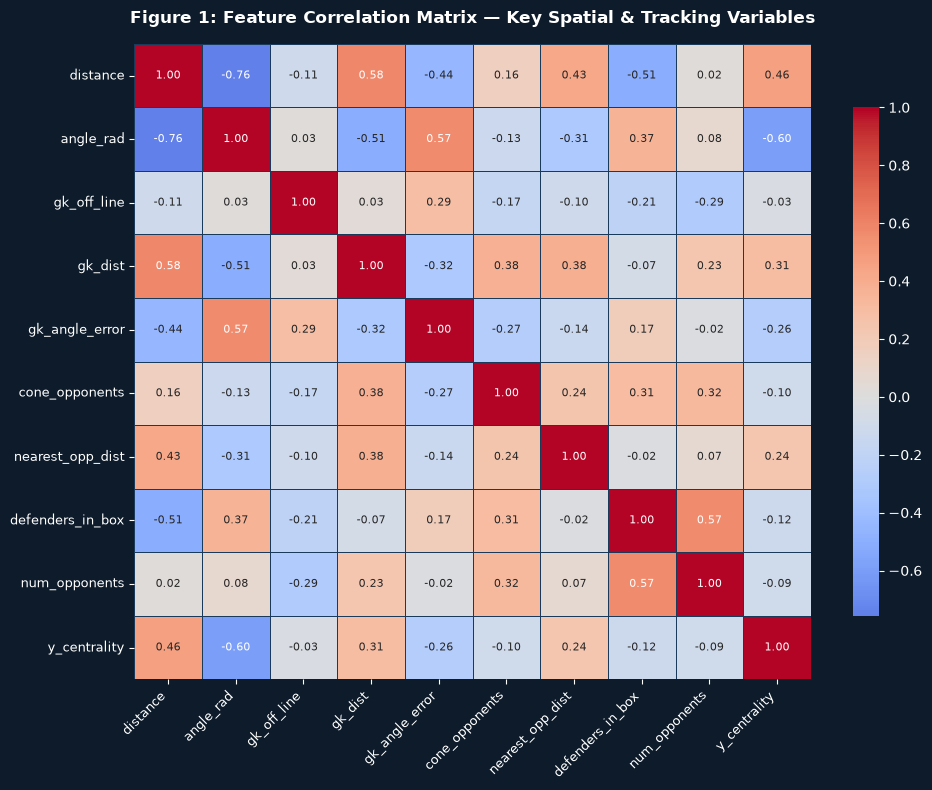

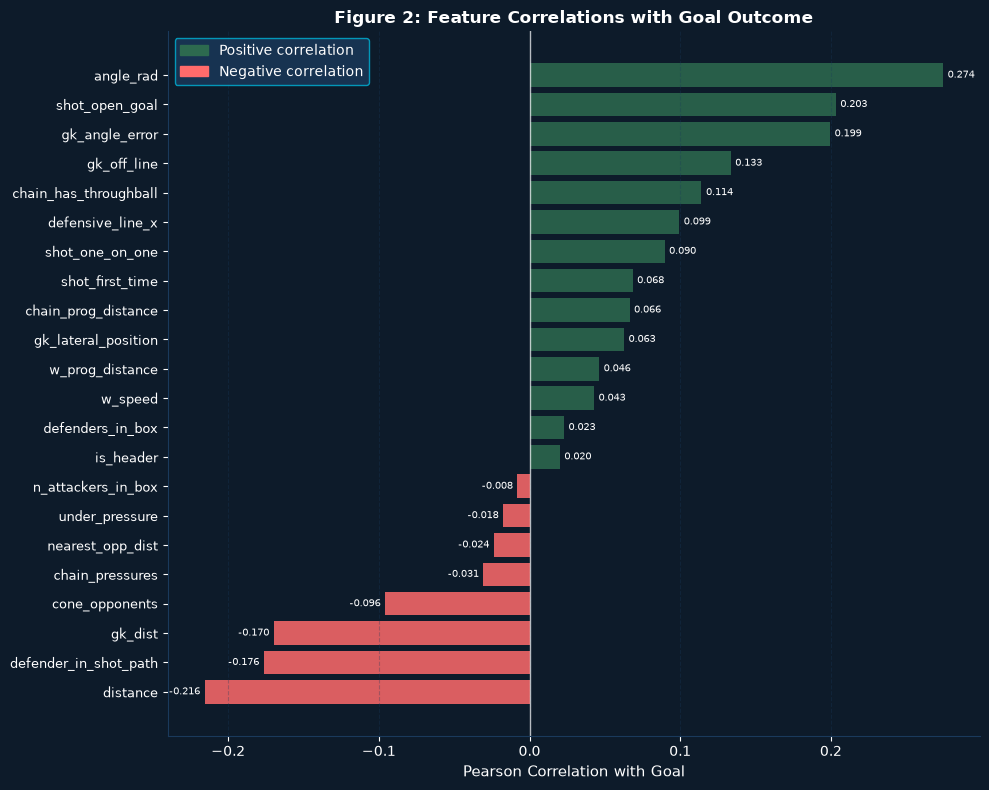

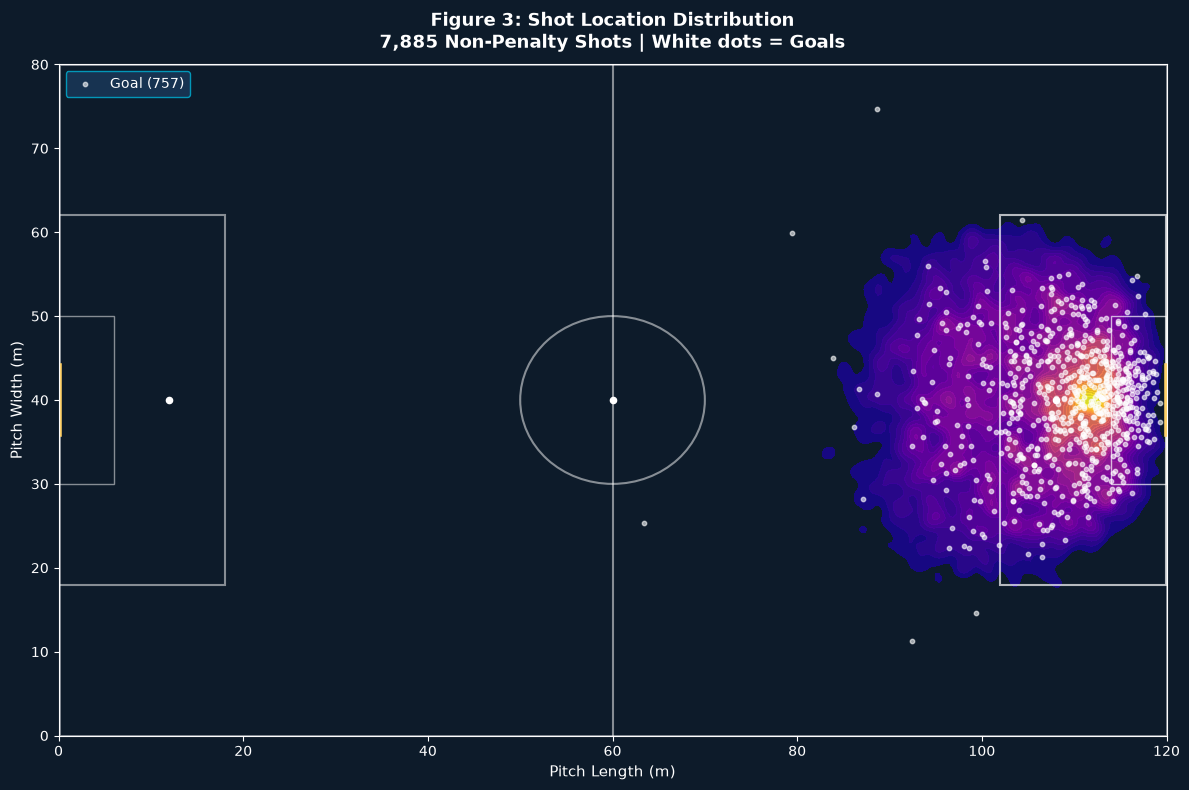

In [26]:
# ── FIGURE 1: Correlation Matrix Heatmap ──────────────────────────────────────
os.makedirs('figures', exist_ok=True)

corr_cols = ['distance', 'angle_rad', 'gk_off_line', 'gk_dist',
             'gk_angle_error', 'cone_opponents', 'nearest_opp_dist',
             'defenders_in_box', 'num_opponents', 'y_centrality']

corr_matrix = df_rich[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, annot_kws={'size': 8}, linewidths=0.5, linecolor=DARK,
            cbar_kws={'shrink': 0.8})

ax.set_title('Figure 1: Feature Correlation Matrix — Key Spatial & Tracking Variables',
             color='white', fontsize=12, fontweight='bold', pad=15)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(rotation=0, color='white')
plt.tight_layout()
plt.savefig('figures/figure1_correlation_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── FIGURE 2: Feature Correlations with Goal ──────────────────────────────────
corr_cols_goal = [
    'distance', 'angle_rad', 'gk_off_line', 'gk_dist', 'gk_angle_error',
    'cone_opponents', 'nearest_opp_dist', 'defenders_in_box', 'is_header',
    'shot_first_time', 'shot_one_on_one', 'shot_open_goal', 'under_pressure',
    'chain_has_throughball', 'defensive_line_x', 'chain_prog_distance',
    'w_speed', 'w_prog_distance', 'chain_pressures', 'gk_lateral_position',
    'defender_in_shot_path', 'n_attackers_in_box'
]

goal_corr = df_rich[corr_cols_goal + ['is_goal']].corr()['is_goal'].drop('is_goal')
goal_corr = goal_corr.sort_values()

colors_bar = [GREEN if v > 0 else RED for v in goal_corr.values]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.barh(range(len(goal_corr)), goal_corr.values, color=colors_bar, alpha=0.85)
ax.set_yticks(range(len(goal_corr)))
ax.set_yticklabels(goal_corr.index, color='white', fontsize=9)
ax.axvline(x=0, color='white', linewidth=1, alpha=0.7)
ax.set_xlabel('Pearson Correlation with Goal', color='white', fontsize=11)
ax.set_title('Figure 2: Feature Correlations with Goal Outcome', color='white',
             fontsize=12, fontweight='bold')
ax.tick_params(colors='white')

for i, v in enumerate(goal_corr.values):
    ax.text(v + (0.003 if v >= 0 else -0.003), i, f'{v:.3f}', va='center',
            ha='left' if v >= 0 else 'right', color='white', fontsize=7)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color(DARK)
ax.grid(axis='x', color=DARK, linestyle='--', alpha=0.3)

green_patch = mpatches.Patch(color=GREEN, label='Positive correlation')
red_patch = mpatches.Patch(color=RED, label='Negative correlation')
ax.legend(handles=[green_patch, red_patch], facecolor=DARK, labelcolor='white',
          edgecolor=BLUE, fontsize=10)

plt.tight_layout()
plt.savefig('figures/figure2_goal_correlations.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── FIGURE 3: Shot Location Distribution ──────────────────────────────────────
from scipy.stats import gaussian_kde

df_rich['x'] = df_rich['location'].apply(lambda loc: loc[0])
df_rich['y'] = df_rich['location'].apply(lambda loc: loc[1])

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

x_coords = df_rich['x'].values
y_coords = df_rich['y'].values
goals_mask = df_rich['is_goal'] == 1

xy = np.vstack([x_coords, y_coords])
kde = gaussian_kde(xy, bw_method=0.08)
xi = np.linspace(0, 120, 400)
yi = np.linspace(0, 80, 400)
Xi, Yi = np.meshgrid(xi, yi)
Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)

threshold = Zi.max() * 0.04
levels = np.linspace(threshold, Zi.max(), 30)
ax.contourf(Xi, Yi, Zi, levels=levels, cmap='plasma', alpha=0.9)

ax.add_patch(mpatches.Rectangle((0, 0), 120, 80, linewidth=2, edgecolor='white', facecolor='none', alpha=0.5))
ax.axvline(x=60, color='white', linewidth=1.5, alpha=0.5)
ax.scatter([60], [40], color='white', s=20, zorder=6)
ax.add_patch(plt.Circle((60, 40), 10, fill=False, color='white', linewidth=1.5, alpha=0.5))

ax.add_patch(mpatches.Rectangle((0, 18), 18, 44, linewidth=1.5, edgecolor='white', facecolor='none', alpha=0.5))
ax.add_patch(mpatches.Rectangle((0, 30), 6, 20, linewidth=1, edgecolor='white', facecolor='none', alpha=0.5))
ax.scatter([12], [40], color='white', s=20, zorder=6)

ax.add_patch(mpatches.Rectangle((102, 18), 18, 44, linewidth=1.5, edgecolor='white', facecolor='none', alpha=0.7))
ax.add_patch(mpatches.Rectangle((114, 30), 6, 20, linewidth=1, edgecolor='white', facecolor='none', alpha=0.7))
ax.scatter([108], [40], color='white', s=20, zorder=6)

ax.plot([0, 0], [36, 44], color=GOLD, linewidth=4)
ax.plot([120, 120], [36, 44], color=GOLD, linewidth=4)

ax.scatter(df_rich[goals_mask]['x'], df_rich[goals_mask]['y'], c='white', s=10, alpha=0.6,
           zorder=5, label=f'Goal ({goals_mask.sum():,})')

ax.set_xlim(0, 120)
ax.set_ylim(0, 80)
ax.set_xlabel('Pitch Length (m)', color='white', fontsize=11)
ax.set_ylabel('Pitch Width (m)', color='white', fontsize=11)
ax.set_title(f'Figure 3: Shot Location Distribution\n{len(df_rich):,} Non-Penalty Shots | White dots = Goals',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
ax.legend(facecolor=DARK, labelcolor='white', edgecolor=BLUE, fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('figures/figure3_shot_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()